In [1]:
!rsync -avz cluster.ies:/mnt/work/dhuseljic/experiments/mlflow/boss /home/dhuseljic/mlflow/

receiving incremental file list

sent 25 bytes  received 104 bytes  86.00 bytes/sec
total size is 87,658,496  speedup is 679,523.22


In [5]:
import mlflow
import numpy as np
import pylab as plt
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib as mpl
from cycler import cycler

# Define a custom style dictionary
custom_style = {
    # Figure and axes
    "figure.figsize": (10, 6),
    "figure.dpi": 100,
    "axes.facecolor": "white",
    "axes.edgecolor": "lightgray",
    
    # Lines and markers
    "lines.linewidth": 1.5,
    "lines.markersize": 6,

    # Font settings
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],

    # Save figure settings
    "savefig.dpi": 300,
}

# Update matplotlib's global rcParams with your custom style
mpl.rcParams.update(custom_style)
mpl.rcParams['axes.grid'] = True
mpl.rcParams["grid.linestyle"] = '--'
mpl.rcParams["grid.linewidth"] = .5
mpl.rcParams["grid.alpha"] = 0.7
# mpl.rcParams['axes.prop_cycle'] = cycler("color", plt.get_cmap("Set2").colors)
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["#6C8EBF", "#D45D5D", "#5C985C", "#D9822B", "#9C7AA1", "#DAB66C", "#A2D5C6", "#E699B3"])
    # "grid.color": "gray",

import os
from pathlib import Path

plot_dir = Path('/home/dhuseljic/paper_plots/boss/')
os.makedirs(plot_dir, exist_ok=True)

# uri = 'sqlite:////home/dhuseljic/mlflow/perf_dal/perf_dal_2.db'
uri = 'sqlite:////home/dhuseljic/mlflow/boss/bert.db'
client = mlflow.tracking.MlflowClient(tracking_uri=uri)

# uri = 'sqlite:////home/dhuseljic/mlflow/perf_dal/perf_dal_2.db'
for exp in client.search_experiments():
    print(exp.name)

miniLM_oracle
bert_baselines_v6
bert_oracle_v4
bert_baselines_v4
bert_oracle
bert_baselines_v3
bert_baselines_v2
bert_baselines
Default


In [6]:
def get_runs(uri, exp_name, query_list="", after=None, before=None):
    client = mlflow.tracking.MlflowClient(tracking_uri=uri)
    experiment_id = client.get_experiment_by_name(exp_name).experiment_id
    runs = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
    if after is not None:
        runs = [run for run in runs if (run.info.end_time / 1000) > after]
    if before is not None:
        runs = [run for run in runs if (run.info.end_time / 1000) < before]
    runs = sorted(runs, key=lambda run: int(run.data.params['random_seed']))
    print(f'Got {len(runs)} runs for experiments {exp_name} with query {query_list}.')
    return runs

def get_metric(run, metric):
    m_values = [m.value for m in client.get_metric_history(run.info.run_id, metric)]
    return m_values

def get_avg_lc(runs, metric='accuracy', return_std=False):
    lcs = []
    for run in runs:
        m_values = get_metric(run, metric)
        if len(m_values) == 0:
            print(f'No metric values found for run {run.info.run_id}.')
        if len(m_values) != 21:
            continue
        lcs.append(m_values)
    avg_lc = np.mean(lcs, axis=0)
    if return_std:
        std_lc = np.std(lcs, axis=0)
        return avg_lc, std_lc 
    return avg_lc
    

In [7]:
all_runs = get_runs(uri, 'bert_baselines_v6', query_list=["parameter.optimizer.lr = '0.1'"])
all_runs.extend(get_runs(uri, 'miniLM_oracle'))

Got 320 runs for experiments bert_baselines_v6 with query ["parameter.optimizer.lr = '0.1'"].
Got 40 runs for experiments miniLM_oracle with query .


In [8]:
ds_names = np.unique([run.data.params['dataset_name'] for run in all_runs]).tolist()
strategy_names = np.unique([run.data.params['al.strategy'] for run in all_runs]).tolist()

learning_curves = defaultdict(dict) # dataset -> strat -> accs
al_setup = dict()

for ds_name in ds_names:
    runs_ds = [run for run in all_runs if ds_name == run.data.params['dataset_name']]
    params = runs_ds[0].data.params
    al_setup[ds_name] = dict(
        num_acq=eval(params['al.num_acq']),
        acq_size=eval(params['al.acq_size']),
        num_init=eval(params['al.num_init']),
    )

    # al_setup[ds_name] = 

    for strat_name in strategy_names:
        runs_strat = [run for run in runs_ds if strat_name == run.data.params['al.strategy']]
        accs_strat = np.array([get_metric(run, 'accuracy') for run in runs_strat])
        learning_curves[ds_name][strat_name] = accs_strat

    

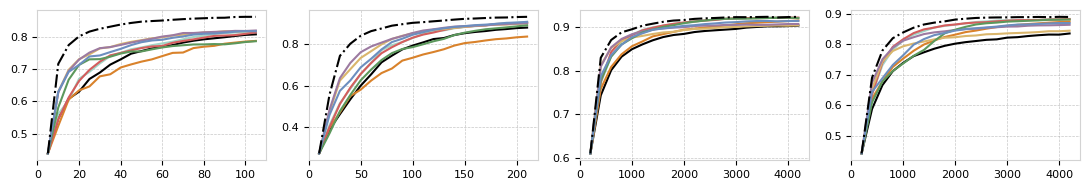

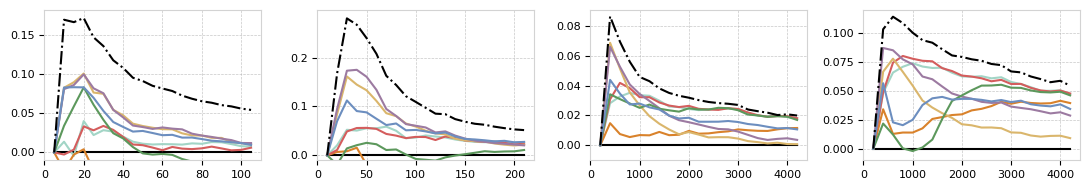

In [26]:
plot_kwargs = {
    'alfamix' :         dict(c='C0', ls='-', alpha=1, label='AlfaMix'),
    'badge' :           dict(c='C1', ls='-', alpha=1, label='BADGE'),
    'bait' :            dict(c='C2', ls='-', alpha=1, label='BAIT'),
    'coreset' :         dict(c='C3', ls='-', alpha=1, label='CoreSets'),
    'dropquery' :       dict(c='C4', ls='-', alpha=1, label='DropQuery'),
    'typiclust' :       dict(c='C5', ls='-', alpha=1, label='TypiClust'),
    'margin' :          dict(c='C6', ls='-', alpha=1, label='Margin'),
    'random' :          dict(c='k' , ls='-', alpha=1, label='Random'),
    'perf_dal_oracle' : dict(c='k', ls='-.', alpha=1, label='BoSS'),
}

datasets_ordered = ['agnews', 'dbpedia', 'banking77', 'clinc']
# strats_ordered = ['random', 'margin', 'coreset', 'badge', 'typiclust', 'dropquery', 'bait', 'alfamix']
strats_ordered = ['random', 'margin', 'coreset', 'badge', 'typiclust', 'dropquery', 'bait', 'alfamix', 'perf_dal_oracle']

fig, ax = plt.subplots(nrows=1, ncols=4, tight_layout=True, figsize=(11, 2))
for i_ds, ds_name in enumerate(datasets_ordered):
    i_ax = ax[i_ds]
    plt.sca(i_ax)
    i_ax.tick_params(axis='both', which='major', labelsize=8)
    i_ax.tick_params(axis='both', which='minor', labelsize=8)
    als = al_setup[ds_name]
    axis = np.arange(als['num_init'], als['acq_size']*(als['num_acq']+2), als['acq_size'])
    learning_curves_dataset = learning_curves[ds_name]

    for strat in strats_ordered:
        accs = learning_curves_dataset[strat]
        # print(strat, accs.shape)
        avg_lc = np.mean(accs, 0)
        plt.plot(axis, avg_lc, **plot_kwargs[strat])

        learning_curves[ds_name]
#plt.legend(ncol=5, loc=1, bbox_to_anchor=(0, 1.4))
plt.tight_layout()
plt.savefig(plot_dir / 'lc_acc_boss_text.pdf', bbox_inches='tight')

fig, ax = plt.subplots(nrows=1, ncols=4, tight_layout=True, figsize=(11, 2))
for i_ds, ds_name in enumerate(datasets_ordered):
    i_ax = ax[i_ds]
    plt.sca(i_ax)
    i_ax.tick_params(axis='both', which='major', labelsize=8)
    i_ax.tick_params(axis='both', which='minor', labelsize=8)
    als = al_setup[ds_name]
    axis = np.arange(als['num_init'], als['acq_size']*(als['num_acq']+2), als['acq_size'])
    learning_curves_dataset = learning_curves[ds_name]
    accs_random = learning_curves_dataset['random']
    avg_lc_random = np.mean(accs_random, axis=0)

    for strat in strats_ordered:
        accs = learning_curves_dataset[strat]
        avg_lc = np.mean(accs, axis=00)
        plt.plot(axis, avg_lc - avg_lc_random, **plot_kwargs[strat])

        learning_curves[ds_name]
    ylim = plt.ylim()
    plt.ylim(-0.01, ylim[1])
# plt.legend(ncol=5, loc=1, bbox_to_anchor=(0, 1.4))
fig.tight_layout()
plt.savefig(plot_dir / 'lc_relacc_boss_text.pdf', bbox_inches='tight')